# Capítulo 3: Integración numérica o cuadratura

> [3.1. Fórmulas de Newton-Côtes](#sec:for.new.cotes)
>
> [3.2. Análisis del error para las fórmulas de Newton-Côtes](#sec:an.error.for.new.cotes)
>
> [3.3. Fórmulas de Newton-Côtes compuestas](#sec:for.new.cotes.comp)
>
> [3.4. Análisis del error para las fórmulas de Newton-Côtes compuestas](#sec:an.error.for.new.cotes.comp)
>
> [3.5 Integración compuesta para una serie de datos](#sec:int.comp.datos)
>
> [3.6. Cómo estimar integrales con la precisión deseada](#sec:est.int.con.pre.des)

# Integración numérica o cuadratura

El objetivo de este capítulo es hallar fórmulas que permitan calcular integrales (aproximadas) pero de cualquier función. Cuando decimos *aproximadas* queremos decir con tanta precisión como se desee.

Queremos calcular por ejemplo
$$
\int_0^A e^{-x^2} \, dx \qquad\text{o} \qquad
\int_6^5 \frac{t^3}{e^t-1} \, dt
$$
que no tienen una expresión analítica.

Integrales difíciles de resolver analíticamente suelen aparecer al calcular el área de superficies de revolución.
Recordamos que el área de la superficie de revolución que se obtiene al girar el gráfico de $y = f(x)$ alrededor del eje $x$, para $a \le x \le b$ es
$$
\int_a^b 2\pi f(x) \sqrt{1+f'(x)^2} \, dx.
$$
Rara vez el integrando de esta expresión se podrá integrar analíticamente, y son muy útiles los métodos numéricos. Estos no nos dan una fórmula cerrada para el resultado, pero permiten calcular la integral con tanta precisión como se desee.

---

## 3.1. Fórmulas de Newton-Côtes <a name = "sec:for.new.cotes" ></a>

Supongamos que se desea calcular la integral
$$
\int_a^b f(x) \, dx
$$
para una función dada $f$.

La idea de las fórmulas de Newton-Côtes es interpolar la función $f$ en $n$ puntos equiespaciados con un polinomio de grado $\le n-1$ e integrar el polinomio.

Por ejemplo, para $n=1$ tomamos el punto medio, y el polinomio de grado cero que interpola en ese punto es la función constante $p_1(x) = f(\frac{a+b}2)$. Resulta
$$
\int_a^b f(x) \, dx \approx \int_a^b p_1(x) \, dx = \int_a^b f(\frac{a+b}2) \, dx
= \underbrace{(b-a)f(\frac{a+b}2)}_{Q_1(f;a,b)}.
$$
Esta fórmula se conoce como *Regla del rectángulo*, porque estamos calculando el área del rectángulo con base $(b-a)$ y altura $f(\frac{a+b}2)$.

Para $n=2$ podemos escribir el polinomio $p_2$ que interpola a $f$ en $x=a$ y en $x=b$ de la siguiente manera
$$
p_2(x) = \frac{b-x}{b-a} f(a) + \frac{x-a}{b-a} f(b).
$$
Luego
$$
\int_a^b f(x) \, dx \approx \int_a^b p_2(x) \, dx
= \dots = \underbrace{ (b-a) \left( \frac12 f(a) + \frac12 f(b) \right)}_{Q_2(f;a,b)}.
$$
Esta fórmula se conoce como *Regla del trapecio*, porque estamos calculando el área del trapecio con bases $f(a)$, $f(b)$ y altura $(b-a)$.

Para $n=3$ podemos escribir el polinomio $p_3$ que interpola a $f$ en $x=a$, $x=m=\frac{a+b}2$ y en $x=b$ de la siguiente manera
$$
p_3(x) = \frac{(b-x)(m-x)}{(b-a)(m-a)} f(a) + \frac{(b-x)(a-x)}{(b-m)(a-m)} f(m)
+ \frac{(x-a)(x-m)}{(b-a)(b-m)} f(b).
$$
Luego
$$
\int_a^b f(x) \, dx \approx \int_a^b p_3(x) \, dx
= \dots = \underbrace{(b-a) \left( \frac16 f(a) + \frac46 f(m) + \frac16 f(b) \right)}_{Q_3(f;a,b)}.
$$
Esta fórmula se conoce como *Regla de Simpson*.

Las operaciones que no escribimos y que irían en $\cdots$ son muy laboriosas.
Lo importante de entender aquí son dos cosas:

1. Las fórmulas de integración numérica consisten en evaluar $f$ en distintos puntos del intervalo, multiplicar esos valores por otros números, sumar, y finalmente multiplicar por la longitud del intervalo.

2. Las fórmulas deberían ser exactas cuando se la aplicamos a un polinomio $p$ de grado $\le n-1$, es decir:

   $$
   \int_a^b p(x) \, dx = Q_n (p,a,b)
   $$

   ¿Por qué? Porque si interpolamos un polinomio de grado $\le n-1$ en $n$ puntos, obtenemos el mismo polinomio original. Entonces integrar ese polinomio nos da la integral de la función de partida.



> ### Definición
> Una **fórmula de integración numérica o de cuadratura** consiste de $n$ puntos $x_1$, $x_2$, $\dots$, $x_n$ en el intervalo y $n$ *pesos* $w_1$, $w_2$, $\dots$, $w_n$ de modo que

$$
\int_a^b f(x) \, dx \approx (b-a) \sum_{i=1}^n w_i f(x_i) =: Q_n(f;a,b).
$$

Para hallar los $w_i$ correspondientes a la fórmula de Newton-Côtes de $n$ puntos, consideramos el intervalo $[0,1]$ y recordamos que debería cumplirse que para todo polinomio de grado $\le n-1$

$$
\int_a^b p(x) \, dx = Q_n (p;a,b) = \sum_{i=1}^n w_i p(x_i).
$$

En particular debería cumplirse para $p_0(x) = 1$, para $p_1(x) = x$, para $p_2(x) = x^2$, $\dots$, y para $p_{n-1}(x) = x^{n-1}$.
Luego

\begin{align*}
p_0(x) &= 1 & \int_0^1 1\, dx = 1 &= w_1 + w_2 + \dots + w_n\\
p_1(x) &= x & \int_0^1 x\, dx = \frac12 &= w_1 x_1 + w_2 x_2 + \dots + w_n x_n\\
p_2(x) &= x^2 & \int_0^1 x^2\, dx = \frac13 &= w_1 x_1^2 + w_2 x_2^2 + \dots + w_n x_n^2\\
&\vdots \\
p_{n-1}(x) &= x^{n-1} & \int_0^1 x^{n-1}\, dx = \frac1n &= w_1 x_1^{n-1} + w_2 x_2^{n-1} + \dots + w_n x_n^{n-1}.
\end{align*}

Tomando los puntos $x_1,\dots,x_n$ equiespaciados en $[0,1]$, es decir, $x_1 = 0$, $x_2 = 1/(n-1)$, $x_3 = 2/(n-1)$ $\dots$, $x_n = 1$ (`x=np.linspace(0,1,n)`), sólo nos queda determinar los pesos $w_i$ de la fórmula. Entonces vemos que los pesos $w_i$ son las soluciones del siguiente sistema de ecuaciones

\begin{align*}
  w_1 + w_2 + \dots + w_n &= 1\\
w_1 x_1 + w_2 x_2 + \dots + w_n x_n &= \frac12\\
 w_1 x_1^2 + w_2 x_2^2 + \dots + w_n x_n^2 &= \frac13\\
&\,\,\vdots \\
w_1 x_1^{n-1} + w_2 x_2^{n-1} + \dots + w_n x_n^{n-1}&= \frac1n.
\end{align*}

En forma matricial

$$
\begin{bmatrix}
1 & 1 &  \dots & 1 \\
x_1 & x_2 & \dots & x_n \\
x_1^2 & x_2^2 & \dots & x_n^2 \\
&\vdots \\
x_1^{n-1} & x_2^{n-1} & \dots & x_n^{n-1}
\end{bmatrix}
\begin{bmatrix}
w_1 \\ w_2 \\ \vdots \\ w_n
\end{bmatrix}
=
\begin{bmatrix}
1 \\ \frac12 \\ \vdots \\ \frac1n
\end{bmatrix}
$$

Por lo tanto, los pesos de la fórmula de Newton-Côtes se encuentran resolviendo ese sistema.

Existen otras maneras de hallar los pesos que son más precisas si $n$ es grande, pero para $n\le 10$ (que es lo que utilizaremos nosotros), esta manera es práctica.

El siguiente código calcula, dado un entero positivo $n$, los pesos $w_i$ tomando las abscisas $x_i$ equiespaciadas en el intervalo $[0,1]$.

In [ ]:
import numpy as np

def pesosNC(n):
    # Calcula los pesos de la fórmula de Newton-Cotes de n puntos
    x = np.linspace(0, 1, n)
    A = np.ones((n, n))
    for i in range(1, n):
        A[i, :] = A[i-1, :] * x
    b = 1 / np.arange(1, n+1)
    w = np.linalg.solve(A, b)
    return w

El siguiente código calcula la integral aproximada de una función $f$ utilizando la fórmula de Newton-Côtes de $n$ puntos. Las abscisas se calculan tomando $n$ puntos equiespaciados en el intervalo $[a,b]$ (usando `np.linspace`).

In [ ]:
import numpy as np

def integralNC(f,a,b,n):
    w = pesosNC(n)
    x = np.linspace(a,b,n)
    y = f(x)
    Q = (b - a)*np.sum(y * w)
    return Q

> ### Desafío
Compruebe su funcionamiento integrando $f(x)=\sin(x)$ en el $[0,\pi]$ tanto analíticamente como numéricamente usando `integralNC` para diferentes $n$.

In [ ]:
# Utilice esta celda para resolver el desafío

---

## 3.2. Análisis del error para las fórmulas de Newton-Côtes <a name = "sec:an.error.for.new.cotes" ></a>

Dada una función suave $f$ en el intervalo $[a,b]$, ¿Qué error se comete al calcular la integral con la fórmula de Newton-Côtes de $n$ puntos?

Para saber esto, recordemos que

$$
Q_n(f;a,b) = \int_a^b p_n(x) \, dx
$$

con $p_n$ el polinomio de grado $\le n-1$ que interpola a $f$ en $n$ puntos.
Este polinomio satisface, según el Corolario 2.7 del capítulo anterior

$$
\max_{x\in[a,b]} |f(x)-p_n(x)| \le \frac{M_n}{n} \frac{|b-a|^n}{(n-1)^n},
$$

con $M_n = \max_{\xi\in[a,b]} |f^n(\xi)|$.

Por lo tanto


\begin{align*}
\left| \int_a^b f(x) \, dx - Q_n(f;a,b) \right|
&= \left| \int_a^b f(x) \, dx - \int_a^b p_n(x)\,dx \right|
\\
&= \left| \int_a^b f(x) -p_n(x)\, dx  \right|
\le \int_a^b |f(x) -p_n(x)| \, dx
\\
&\le |b-a| \frac{M_n}{n} \frac{|b-a|^n}{(n-1)^n}
= \frac{M_n}{n} \frac{|b-a|^{n+1}}{(n-1)^n}
\end{align*}

Hemos demostrado entonces el siguiente teorema.


> ### Teorema 3.1 <a name = "teo:error.cuadratura"></a>
> Si $f$ es una función $C^{n}$ en $[a,b]$, entonces
>
> $$
\left|\int_a^b f(x) \,dx - Q_n(f;a,b) \right|
\le \frac{M_{n} |b-a|^{n+1}}{n (n-1)^n},
$$
>
> con $M_n = \max_{\xi\in[a,b]} |f^n(\xi)|$.

Esta cota del error entre la integral exacta y la aproximada tiene el mismo problema que la cota del error de interpolación. Hay muchas funciones para las que ese término **no** tiende a cero (cuando $M_n \to \infty$ rápidamente.) Este problema se resuelve utilizando las fórmulas de Newton-Côtes compuestas que veremos en la siguiente sección.


---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Error Newton-Côtes 1</font>

Para cada una las siguientes funciones $f$, calcule a mano la integral de $f$, $I(f,0,5) = \int_0^5 f(x)~dx$, las aproximaciones dadas por la regla del trapecio $Q_2(f,0,5)$ y de Simpson $Q_3(f,0,5)$, y los errores asociados a ambas aproximaciones. Explique los resultados.

$f(x) = -2x + 1$.

$f(x) = 3.5 x^2 + 2 x - 56$.

$f(x) = -1.5 x^3 - x^2 + 7.6$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Error Newton-Côtes 2</font>

Recordemos que $Q_n(f,a,b)$ denota la fórmula de Newton-Cotes de $n$ puntos en el intervalo $[a,b]$.

1. Completar los siguientes cuadros y verificar si el error entre $\int_a^b f(x) dx$ y $Q_n(f,a,b)$ tiende a cero a medida que $n$ crece.

$f(x) = \sin(\pi x)$, en $[a,b]= [0,5]$

| $n$ | $\int_{0}^5 f(x)dx - Q_n(f,0,5)$ |
|--|--|
| $$2$$ |  |
| $$3$$ |  |
| $$4$$ |  |
| $$5$$ |  |
| $$6$$ |  |
| $$7$$ |  |
| $$8$$ |  |
| $$9$$ |  |
| $$10$$ |  |
| $$11$$ |  |
| $$12$$ |  |
| $$13$$ |  |

$f(x) = \frac{1}{1+x^2}$, en $[a,b]= [-5,5]$

| $n$ | $\int_{-5}^5 f(x)dx - Q_n(f,-5,5)$ |
|--|--|
| $$2$$ |  |
| $$3$$ |  |
| $$4$$ |  |
| $$5$$ |  |
| $$6$$ |  |
| $$7$$ |  |
| $$8$$ |  |
| $$9$$ |  |
| $$10$$ |  |
| $$11$$ |  |
| $$12$$ |  |
| $$13$$ |  |

*Sugerencia: Para analizar tablas de errores lo más importante son los dos primeros dígitos significativos del error y su magnitud, no hace falta escribir tantos dígitos.*

2. Para cada una de las funciones del item anterior, realizar el gráfico de $f$ y de los polinomios interpolantes en $n$ puntos equidistribuidos del intervalo $[a,b]$, para los valores de $n$ en la tabla. Relacionar los resultados del item anterior con los gráficos obtenidos.

3. ¿Es cierto que $\lim_{n\to\infty} Q_n(f,a,b) =  \int_a^b f(x) dx$, para toda función $f$?



In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

## 3.3. Fórmulas de Newton-Côtes compuestas <a name = "sec:for.new.cotes.comp" ></a>

La idea principal de estas fórmulas es integrar en lugar del interpolante polinomial de todo el intervalo un interpolante polinomial a trozos.

Particionamos el intervalo $[a,b]$ en $L$ sub-intervalos de longitud $h = \dfrac{b-a}L$. Definimos

$$
z_1 = a, \quad z_2 = a+h, \quad z_3 = a+2h, \quad\dots\quad
z_L = a+(L-1)h = b-h, \quad z_{L+1} = a+Lh = b,
$$

y observamos que

$$
\int_a^b f(x) \,dx = \int_{z_1}^{z_2} f(x)\, dx + \int_{z_2}^{z_3} f(x) \, dx + \dots
+ \int_{z_{L}}^{z_{L+1}} f(x)\, dx
= \sum_{i=1}^L \int_{z_i}^{z_{i+1}} f(x) \, dx.
$$

Luego, aproximamos cada integral con una fórmula de Newton-Côtes con $n$ fijo, es decir

$$
\int_{z_i}^{z_{i+1}} f(x) \, dx
\approx Q_n(f,z_i,z_{i+1})
$$

y resulta

$$
\int_a^b f(x) \,dx
\approx \sum_{i=1}^L Q_n(f,z_i,z_{i+1})=:Q_n^L(f;a,b).
$$

Para calcular una integral con este método, podemos usar el siguiente código.

In [ ]:
import numpy as np

def NCcompuesta(f,a,b,L,n):
    " function Q = NCcompuesta(f,a,b,L,n)"
    " aproxima la integral de f sobre [a,b]"
    " utilizando la formula de Newton-Cotes compuesta"
    " de n puntos, subdividiendo en L subintervalos"
    y = np.linspace(a,b,L+1)
    Q = 0
    for i in range(L):
        Q = Q + integralNC(f,y[i],y[i+1],n)
    return Q

Esta implementación es muy ineficiente, pues cada vez que se llama a `integralNC` se calculan los pesos de Newton-Côtes, y estos son los mismos en todos los sub-intervalos. La siguiente, es una implementación un poco más eficiente.

In [ ]:
import numpy as np

def intNCcompuesta(f, a, b, L, n):
    z = np.linspace(a, b, L + 1)
    h = (b - a) / L
    w = pesosNC(n)
    Q = 0
    for i in range(L):
        x = np.linspace(z[i], z[i+1], n)
        y = f(x)
        Q += h * np.sum(y * w)
    return Q

> ### Observación
> La fórmula compuesta correspondiente a $n=2$ se llama *fórmula del trapecio compuesta* y la correspondiente a $n=3$ se llama *fórmula de Simpson compuesta*.


---

## 3.4. Análisis del error para las fórmulas de Newton-Côtes compuestas <a name = "sec:an.error.for.new.cotes.comp" ></a>

Observemos lo siguiente:

\begin{align*}
\left| \int_a^b f(x) \, dx - Q_n^L(f,a,b) \right|
&= \left| \sum_{i=1}^L \int_{z_i}^{z_{i+1}}  f(x) \, dx
- \sum_{i=1}^L Q_n(f,z_i,z_{i+1}) \right|
\\
&\le \sum_{i=1}^L \left|  \int_{z_i}^{z_{i+1}}  f(x) \, dx
-  Q_n(f,z_i,z_{i+1}) \right|
\\
&\le \sum_{i=1}^L \frac{M_n}{n} \frac{\left(\frac{|b-a|}L\right)^{n+1}}{(n-1)^n}
= L \frac{M_n}{n} \frac{\left(\frac{|b-a|}L\right)^{n+1}}{(n-1)^n}
= \frac{M_n}{n} \frac{|b-a|^{n+1}}{(n-1)^n}
\frac1{L^{n}}.
\end{align*}

Aquí hemos usado, en cada sub-intervalo $[z_i,z_{i+1}]$ la estimación del error dada por el [Teorema 3.1](#teo:error.cuadratura).

Hemos entonces demostrado el siguiente teorema.

> ### Teorema 3.2
> Si $f$ es una función $C^n$ en $[a,b]$, entonces <a name = "eq:cota.error.cuadratura.compuesta"></a>
> $$
\left|\int_a^b f(x) dx - Q_n^L(f;a,b) \right|
\le \frac{M_n |b-a|^{n+1}}{n (n-1)^n} \frac{1}{L^{n}}, \qquad (3.1)
$$
> con $M_n = \max_{\xi\in[a,b]} |f^n(\xi)|$.

> ### Observación
> Observemos que si $f \in C^n$, entonces $M_n$ es un número finito, y el lado derecho de la fórmula anterior tiende a cero cuando $L \to \infty$.
Es decir, el error tiende a cero a medida que tomamos $L$ cada vez más grande.
además, cuando mayor sea $n$, más rápido tenderá a cero el error.
>
> Pero ¡Cuidado! El error no tiende a cero si dejamos $L$ fijo y hacemos tender $n$ a infinito. ¿Por qué? Pensar.

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Error Newton-Côtes compuestas 1</font>

Consideremos las fórmulas del trapecio compuesta $Q_2^L(f,a,b)$ y de Simpson compuesta $Q_3^L(f,a,b)$ con parámetro de discretización $h=\frac{b-a}{L}$ en el intervalo $[a,b]$, para aproximar $\int_{a}^b f(x) dx$. Denotemos por $ E^{\text{trap}}_L=\left|\int_{a}^b f(x)dx - Q_2^L(f,a,b)\right|$ y $ E^{\text{simp}}_L=\left|\int_{a}^b f(x)dx - Q_3^L(f,a,b)\right|$ a los respectivos errores de aproximación.

1. Completar las siguientes tablas y verificar si el error tiende a cero. En caso afirmativo, determinar en qué factor se reduce el error cuando se duplica la cantidad de subintervalos.

$$f(x) = \sin(\pi x), en [a,b]=[0,5]$$

| | |Regla de los trapecios | | |Regla de Simpson compuesta | | |
|--|--|--|--|--|--|--|--|
|$$h$$|$$L$$|$$Q_2^L(f,0,5)$$|$E^{\text{trap}}_L$|$\frac{E^{\text{trap}}_{L/2}}{E^{\text{trap}}_{L}}$|$$Q_3^L(f,0,5)$$|$E^{\text{simp}}_L$|$\frac{E^{\text{simp}}_{L/2}}{E^{\text{simp}}_{L}}$|
|$$1/2$$||||$$-$$|||$$-$$|
|$$1/4$$||||||||
|$$1/8$$||||||||
|$$1/16$$||||||||
|$$1/32$$||||||||
|$$1/64$$||||||||
|$$1/128$$||||||||
|$$1/256$$||||||||
|$$1/1024$$||||||||
|$$1/2048$$||||||||
|$$1/4096$$||||||||

$$f(x) = \frac{1}{1+x^2}, en [a,b]=[-5,5]$$

| | |Regla de los trapecios | | |Regla de Simpson compuesta | | |
|--|--|--|--|--|--|--|--|
|$$h$$|$$L$$|$$Q_2^L(f,-5,5)$$|$E^{\text{trap}}_L$|$\frac{E^{\text{trap}}_{L/2}}{E^{\text{trap}}_{L}}$|$$Q_3^L(f,-5,5)$$|$E^{\text{simp}}_L$|$\frac{E^{\text{simp}}_{L/2}}{E^{\text{simp}}_{L}}$|
|$$1/2$$||||$$-$$|||$$-$$|
|$$1/4$$||||||||
|$$1/8$$||||||||
|$$1/16$$||||||||
|$$1/32$$||||||||
|$$1/64$$||||||||
|$$1/128$$||||||||
|$$1/256$$||||||||
|$$1/1024$$||||||||
|$$1/2048$$||||||||
|$$1/4096$$||||||||

$$f(x) = |x|^{3/2}, en [a,b]= [0,5]$$

| | |Regla de los trapecios | | |Regla de Simpson compuesta | | |
|--|--|--|--|--|--|--|--|
|$$h$$|$$L$$|$$Q_2^L(f,0,5)$$|$E^{\text{trap}}_L$|$\frac{E^{\text{trap}}_{L/2}}{E^{\text{trap}}_{L}}$|$$Q_3^L(f,0,5)$$|$E^{\text{simp}}_L$|$\frac{E^{\text{simp}}_{L/2}}{E^{\text{simp}}_{L}}$|
|$$1/2$$||||$$-$$|||$$-$$|
|$$1/4$$||||||||
|$$1/8$$||||||||
|$$1/16$$||||||||
|$$1/32$$||||||||
|$$1/64$$||||||||
|$$1/128$$||||||||
|$$1/256$$||||||||
|$$1/1024$$||||||||
|$$1/2048$$||||||||
|$$1/4096$$||||||||

2. ¿Es cierto en general que $\lim_{L\to\infty} Q_2^L(f,a,b) =  \int_a^b f(x) dx$, para toda función $f$? En caso afirmativo ¿Con qué orden $k$ tiende a cero el error? Es decir, determinar el valor de $k$ tal que $E^{\text{trap}}_L = \mathcal{O}(h^{k})$.

3. ¿Es cierto en general que $\lim_{L\to\infty} Q_3^L(f,a,b) =  \int_a^b f(x) dx$, para toda función $f$? En caso afirmativo ¿Con qué orden $k$ tiende a cero el error? Es decir, determinar el valor de $k$ tal que $E^{\text{simp}}_L = \mathcal{O}(h^{k})$.

4. Para cada una de las tres funciones del item 1: Mirando los valores de la tabla, determinar cuántos subintervalos (y cuántas evaluaciones de $f$) se necesitan para calcular la integral con $7$ dígitos de precisión con la regla de los trapecios. ¿Y con la regla de Simpson compuesta?


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

## 3.5 Integración compuesta para una serie de datos

En ocasiones podemos tener una serie de datos discretos en lugar de una función continua para integrar. En estos casos, no podremos realizar el procedimiento anterior de aumentar la cantidad de subintervalos para relizar la integración compuesta.

Sin embargo, podemos usar los datos para realizar una estimación de la integral definida. Más precisamente, si tenemos una serie de datos $(x_1,y_1) , (x_2,y_2,),...,(x_N,y_N)$, con $x_1<x_2<...<x_N$, podemos usar estos puntos para realizar una interpolación a trozos e integrar de forma compuesta.

A continuación, se presenta el código que realiza el método de trapecios para una serie de datos:

In [ ]:
import numpy as np

def trapcomp(x,y):
    L=len(x)-1
    deltax=np.diff(x) #calcula la diferencia entre cada par de datos sucesivos
    Q=0
    for i in range(0,L):
        Q+=0.5*deltax[i]*(y[i]+y[i+1])
    return Q

Podemos observar que el lazo recorre de a pares de datos para realizar un trapecio entre cada par. Por este motivo, los datos no tienen que estar necesariamente igualmente espaciados.

Se presenta ahora el código para el método de Simpson. En este caso, es necesario que la cantidad de datos sea **impar** (¿por qué?). El código se realiza de manera básica, usando la fórmula de Simpson vista anteriormente. Por lo tanto también hay que tener en cuenta que los datos deben estar igualmente espaciados ($x_{i+1}-x_i=h$ fijo).

In [ ]:
import numpy as np

def simpsoncomp(x,y):
    L=len(x)-1
    if L%2:
        raise ValueError("Atencion: Tiene que dar una cantidad impar de datos.")
        Q=np.nan
        return Q
    h = (x[-1]-x[0])/(L/2)
    Q = h/6 * (y[0] + 4*sum(y[1:-1:2]) + 2*sum(y[2:-2:2]) + y[-1])
    return Q

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Fórmulas de Newton-Côtes compuestas 1</font>

Se registra la concentración química $c$  $(\frac{\text{mg}}{\text{m}^{3}})$ a la salida de un reactor perfectamente agitado y se reporta en la siguiente tabla:

||||||||||
|-----------|----|----|----|----|----|----|----|----|
| $t$ (min) | 0  | 10 | 20 | 30 | 35 | 40 | 45 | 50 |
| $c$ (mg/m$^{3}$) | 10 | 35 | 55 | 52 | 40 | 37 | 32 | 34 |

Tenga  en  cuenta  que  la  cantidad  de  masa  que  entra  o  sale  de  un  reactor  en  un período específico está dada por:
$$ m= \int_{t_{1}}^{t_{2}}Q(t)\cdot c(t)\, dt$$
donde  $t_{1}$  y  $t_{2}$  son  el  tiempo  inicial  y  final  respectivamente,  $c$ representa la función de concentración química  y $Q$ es la tasa de flujo.

Calcule la cantidad de masa del producto químico suponiendo que la tasa de flujo es $Q = 4$  $\frac{\text{m}^{3}}{\text{min}}$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Fórmulas de Newton-Côtes compuestas 2</font>

Se mide la concentración química de la salida de un reactor perfectamente agitado:

||||||||||
|-----------|----|----|----|----|----|----|----|----|
| $t$ (min) | 0  | 1 | 4 | 6 | 8 | 12 | 16 | 20 |
| $c$ (mg/m$^{3}$) | 12 | 22 | 32 | 45 | 58 | 75 | 70 | 48 |

Para una tasa de flujo constante $Q = 0.3$ $\frac{\text{m}^{3}}{\text{s}}$, calcule la masa del producto
químico, en gramos, que sale del reactor entre $t = 0$ y $t =
20$ $\text{min}$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Fórmulas de Newton-Côtes compuestas 3</font>

La masa total de una barra de densidad variable está dada por:
$m=\int_{0}^{L}\rho(x)A_{c}(x)dx$. Donde $m$ representa la masa, $\rho$ la densidad, $A_{c}$ el área de la sección transversal, $x$ representa la distancia a lo largo de la barra y $L$ la longitud total de la barra. Se midieron los siguientes datos para una barra de 12 metros de longitud.

|||||||||
|----------|----|----|----|----|----|----|----|
| $$x (cm)$$ | 0 | 200 | 400 | 600 | 800 | 1000 | 1200 |
| $$\rho(x) (g/cm^{3})$$ | 4 | 3.95 | 3.89 | 3.80 | 3.60 | 3.41 | 3.30 |
| $$A_{c}(x) (cm^{2})$$ | 100 | 103 | 106 | 110 | 120 | 133 | 149.6 |

1. Calcule la masa total de la barra y detalle que fórmula de cuadratura utilizó.

2. Determine la precisión del cálculo del item anterior.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

## 3.6. Cómo estimar integrales con la precisión deseada <a name = "sec:est.int.con.pre.des" ></a>

Consideremos el caso en que queremos estimar la siguiente integral
$$
\int_0^4 \sqrt{ 1+(1-\sin(x))^2 } dx,
$$
con un error menor a $10^{-12}$.

Podríamos comenzar a derivar la función para determinar, dado un $n$, cuál es el $L$ necesario, en base a la cota [(3.1)](#eq:cota.error.cuadratura.compuesta) para tener un error menor que $ 10^{-12}$. Pero esto no parece ser muy práctico.

En lugar de eso, procedemos como sigue:

1. Definimos la función a integrar

In [ ]:
import numpy as np
g = lambda x: np.sqrt(1+(1-np.sin(x))**2)

2. Elegimos un $n$ bajo, (probamos primero con 2 o 3)
y un $L$ no muy grande, por ejemplo 10

In [ ]:
n = 2; L = 10;

3. Calculamos la integral con el método compuesto:

In [ ]:
I = intNCcompuesta(g, 0, 4, L, n)
print(I)

4.959477433489742


4. A partir de ahí vamos duplicando $L$ y volviendo a calcular hasta que veamos que se tiene repetición de los dígitos que queremos tener:

In [ ]:
ListaI = np.array([[I]])

for i in range(6):
    L = 2*L
    I = intNCcompuesta(g, 0, 4, L, n)
    ListaI = np.append(ListaI,np.array([[I]]),axis=0)

print(ListaI)

[[4.95947743]
 [4.94665735]
 [4.94346518]
 [4.94266794]
 [4.94246868]
 [4.94241887]
 [4.94240641]]


5. Si notamos que tarda mucho en converger, entonces aumentamos $n$ y comenzamos de nuevo con L bajo:

In [ ]:
n = 3; L = 5;

ListaI = np.array([[0]])

for i in range(12):
    L = 2*L
    I = intNCcompuesta(g, 0, 4, L, n)
    ListaI = np.append(ListaI,np.array([[I]]),axis=0)

np.set_printoptions(precision=16)
print(ListaI)

Esta manera de calcular integrales nos ayuda a comprender que el método de integración compuesta converge cuando dejamos $n$ fijo y hacemos crecer $L$, y también que converge más rápido si $n$ es más grande (con mayor orden).

> ### Importante 👀
> En este método es que $L$ tiene que ir duplicándose, y no incrementando de a uno. Si se incrementa de a uno, entonces parece que converge porque la solución cambia poco, pero aún se está lejos de la precisión deseada.


---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Integrales funciones complicadas 1</font>

Calcular, con un error absoluto menor a $10^{-3}$, el área de las superficies de revolución que se obtienen al girar la gráfica de $y = f(x)$ alrededor del eje $x$, para $x$ en el intervalo indicado.

1. $f(x) = 2 + \cos(\pi x)$, $x \in [0,2]$.

2. $f(x) = x(x-1)(x-2)+2$, $x \in [0,3]$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Integrales funciones complicadas 2</font>

Calcular el área de la superficie de revolución que se obtiene al girar el gráfico de
$$ f(x) = 1+x+\cos(x),\qquad x \in [0,4], $$
alrededor del eje $x$. Dar el resultado con 12 dígitos exactos.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Integrales funciones complicadas 3</font>

La cúpula de una torre tiene la forma de una superficie de revolución que se obtiene al girar el gráfico de la función $y=f(x)$ alrededor del eje $x$, donde
$$f(x) = 3(x+0.5)\sin^4\left(\frac{x-2.7}{2}\right), \ \ \ x\in [0, 2.4].$$

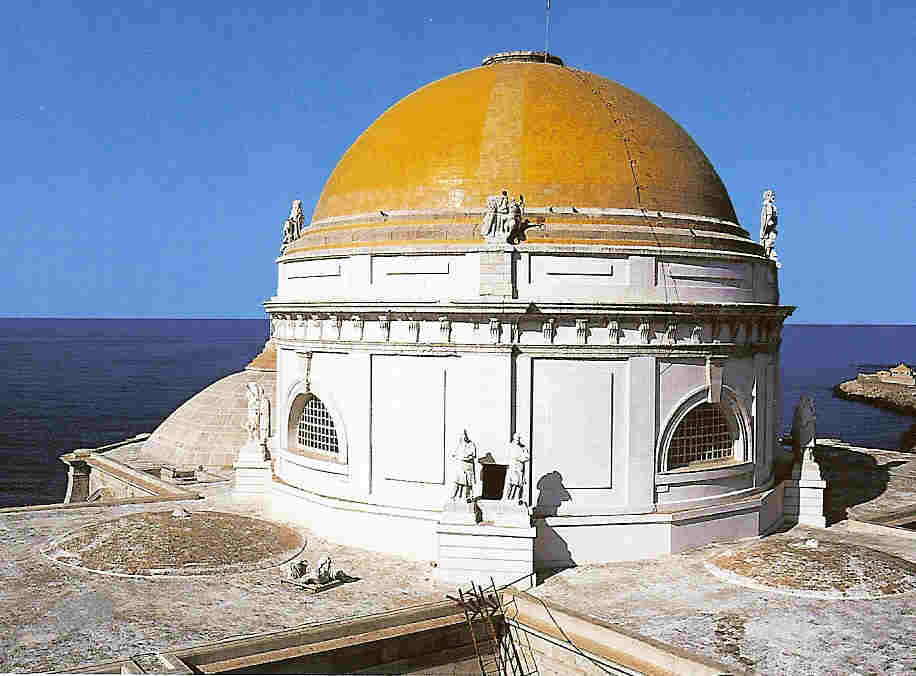
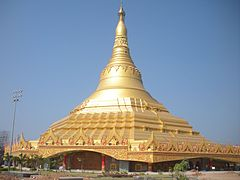
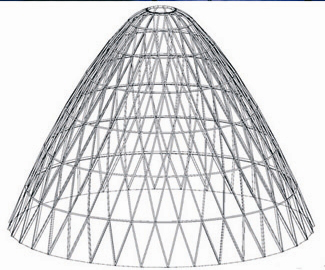






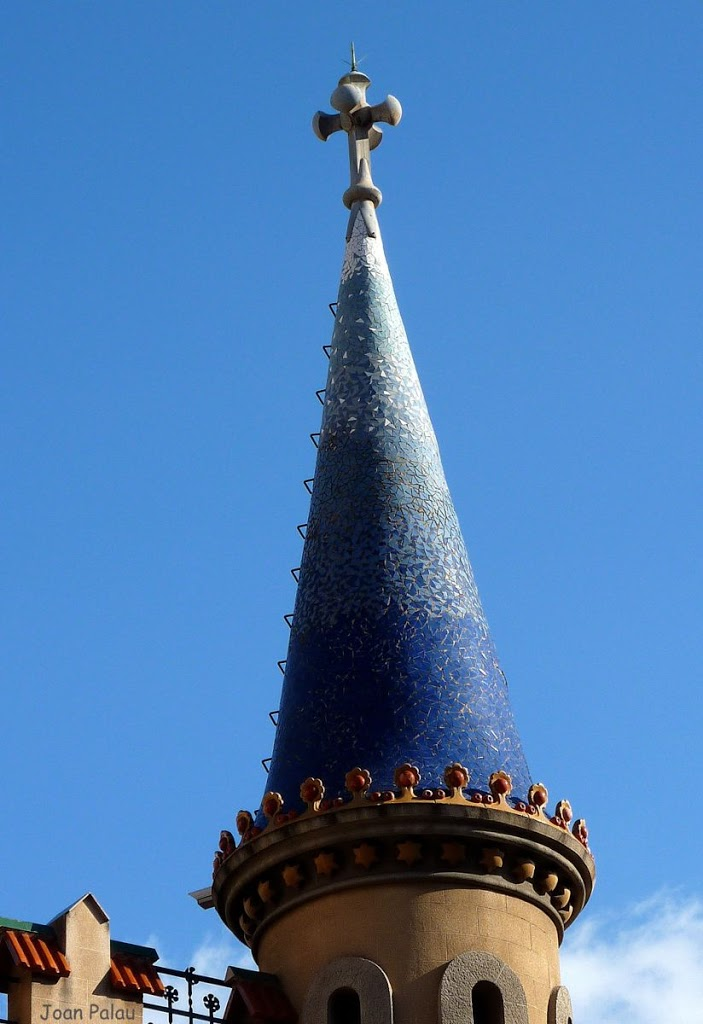






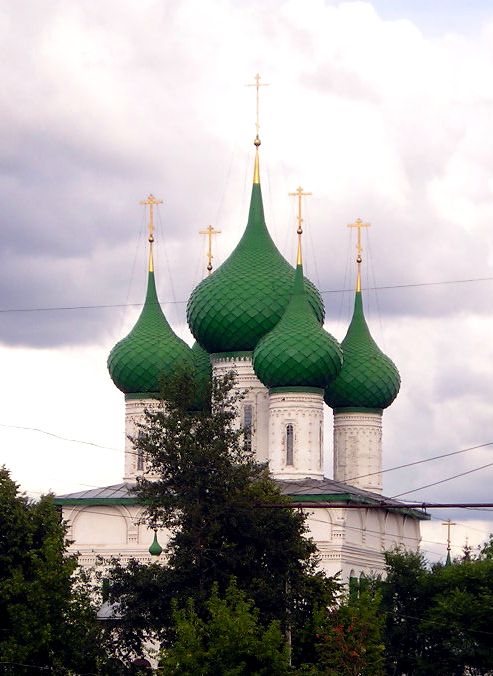









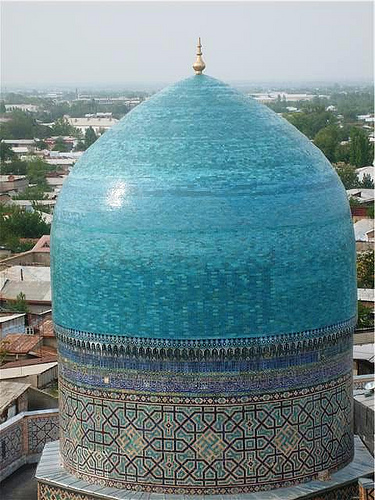



1. Determine a qué tipo de cúpula corresponde entre las ilustradas en la Figura 1. Explique cómo lo hizo.

2. Calcule el área de la cúpula con 6 dígitos exactos si la variable $x$ está expresada en metros. Explique cómo lo hizo.

3. Si con un litro de pintura para exteriores se cubren $7$ $\text{m}^{2}$, ¿Cuánta pintura se necesita para pintar la cúpula si se quiere darle 3 manos?


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

## Ejercicios Adicionales ✍

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en este capítulo. Como verás, no hay un método único para resolver la mayoría de estos ejercicios.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Adicional 1</font>

La Compañía Administradora del Mercado Mayorista Eléctrico (CAMMESA) informó, para el día 16 de septiembre de 2020, los valores de potencia eléctrica generada a través de diferentes fuentes de energía renovable. Las mediciones se realizaron cada 15 minutos a lo largo de todo el día. Además, para cada medición se informó qué porcentaje de la demanda de potencia eléctrica del país se logró cubrir con dichas fuentes renovables.

Los datos se encuentran en el archivo `Energias_renovables.txt`(ver [Datos para el TP3](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13098) en el aula virtual), donde la energía eléctrica generada se mide en MW y el tiempo en horas. Se organizan de la siguiente manera:

| Tiempo | Eólica | Fotovoltaica | Bioenergías | Hidráulica | % demanda cubierta |
|----------|----|----|----|----|----|
| $$0$$ | $$923.13$$ | $$0$$ | $$99.25$$ | $$181.64$$ | $$7.67$$ |
| $$\vdots$$ | $$\vdots$$ | $$\vdots$$ | $$\vdots$$ | $$\vdots$$ | $$\vdots$$ |

1. Realice un gráfico que muestre la evolución de la potencia eléctrica total generada por fuentes renovables a lo largo del día, así como también la evolución de la demanda. Determine los horarios en los cuales se registraron las demandas máxima y mínima, y en qué horario se generó mayor electricidad por fuentes renovables.

2. Calcule la energía eléctrica total (en MWh) generada en todo el día a través de fuentes renovables, así como también la demanda total. ¿Qué porcentaje de la demanda total logró cubrirse por medio de energías renovables?

3. Realice un segundo gráfico donde se muestre la evolución de la potencia eléctrica generada para cada tipo de fuente renovable. ¿En qué horario se registró la mayor potencia fotovoltaica?

4. Calcule el porcentaje de energía eléctrica renovable total que fue generada a partir de energía eólica.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 2</font>

La energía térmica total de un cable en cada instante de tiempo se puede calcular como $E(t) =A\int_0^L c\rho u(x,t)~dx$, donde $A$ denota el área de la sección transversal, $c$ denota del calor específico, $\rho$ la densidad de masa, $u(x,t)$ la temperatura a tiempo $t$ en la posición $x$ del cable que tiene longitud $L$.
Suponga que $L=20$ $\text{cm}$, que $A = 0.15$ $\text{cm}^{2}$, $c = 0.092$ $\frac{\text{cal}}{\text{g}\text{ºC}}$, $\rho = 8.94$ $\frac{\text{g}}{\text{cm}^{3}}$ y que la distribución de la temperatura (en $\text{ºC}$) está dada por $u(x,t)=x(40-x)+(t+1)^2e^{-t}$.

1. Determinar la energía total inicial en el dispositivo.

2. Determinar el momento en el que el cable tiene la máxima energía térmica total.

3. Determinar si la energía total del dispositivo llega a un estado de equilibrio y en caso afirmativo diga cuál es dicho valor.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 3</font>

Considere un dispositivo como el del ejercicio anterior, pero suponga que $L=1$, $A = 0.01$, $c = 1$, $\rho = 1$ y que la distribución de la temperatura $u$ sólo se conoce en $41$ puntos equidistribuidos a lo largo del dispositivo, medidos cada $0.005$ segundos durante los dos primeros segundos y se encuentran en el archivo `datos_temperatura.txt` (ver [Datos para el TP3](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13098) en el aula virtual).

1. Determinar la energía total del dispositivo a tiempo $t = 1$.

2. Determinar la máxima y la mínima energía total alcanzada en el dispositivo y en qué momento ocurren.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 4</font>

La energía térmica total de una placa circular de radio $R=1$ en estado estacionario viene dada por $E = c\rho\int_{-\pi}^{\pi}\int_0^R  u(r,\theta)r~drd\theta$, donde $c$ denota del calor específico, $\rho$ la densidad de masa, $u(r,\theta)$ la temperatura de equilibrio en cada punto $(r,\theta)$ de la placa, para $0<r\le R$ y $-\pi\le\theta\le \pi$. Sabiendo que la temperatura de equilibrio está dada por $u(r,\theta) = 10+ r^3\cos(3\theta) + 2r^2\sin(2\theta)$, determine la energía total $E$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 5</font>

En una planta industrial se decide determinar la cantidad diaria de producto que se pierde a través de una corriente de desecho. Para ello, se toman muestras de dicha corriente cada una hora y se realizan análisis para determinar la concentración del producto ($c$). La masa ($m$) del producto se halla a través de:
	$$ m= \int_{t_{1}}^{t_{2}}Q(t)\cdot c(t)\, dt$$
donde $Q(t)$ es el caudal volumétrico de la corriente de desecho, el cual se asume constante es igual a 30 $\frac{\text{m}^{3}}{\text{h}}$.

En condiciones normales de operación, la concentración del producto en la corriente oscila entre 10 y 15 $\text{ppm}$ (1 $\text{ppm}$ = 1 $\frac{\text{g}}{\text{m}^{3}}$) y presenta variaciones pequeñas respecto al tiempo. En la segunda columna del archivo `datos_muestreo.txt`(ver [Datos para el TP3](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13098) en el aula virtual) se detallan las mediciones de concentración realizadas para estas condiciones.

En determinados casos, por el contrario, ocurren fallas en las etapas de separación del producto, lo que provoca que su concentración en la corriente de desecho aumente bruscamente hasta valores del orden de las 50 $\text{ppm}$. Las fallas pueden detectarse rápidamente, pero el sistema se normaliza recién al cabo de varias horas. En la tercera columna del archivo `datos_muestreo.txt` se da una serie de medidas llevadas a cabo durante uno de estos eventos.

Debido a que el costo de los análisis es elevado, se evalúa la posibilidad de tomar muestras a intervalos mayores de tiempo. Teniendo en cuenta que se desea calcular la masa diaria de producto perdido como desecho con una precisión de 0,1 $\text{kg}$:

1. Para las condiciones normales de operación, determinar en base a los datos suministrados si es posible tomar muestras cada 2 horas y cada 4 horas, conservando la precisión deseada en el cálculo de la masa.

2. Determinar si es posible tomar muestras a intervalos regulares de 2 horas cuando se produce una falla en las etapas de separación. ¿Qué ocurre en este caso?

3. Proponga una solución al problema ocurrido en la situación del Item 2. Para ello, seleccione 12 puntos de muestreo tales que el cálculo de la masa a partir de dichos datos conserve la precisión deseada.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 6</font>

Un jardinero decide delimitar un terreno de la siguiente manera: coloca dos estacas en el suelo, separadas entre sí a una distancia de 7.2 $\text{m}$, ata los extremos de una cuerda de 12 $\text{m}$ de longitud a las estacas y finalmente, apoyando un palo sobre la cuerda tensa, traza el perímetro del terreno.

1. ¿Qué figura geométrica describe el perímetro? Determine sus ecuaciones paramétricas.

2. Calcule cuántos metros de alambre son necesarios para cercar el terreno. Exprese el resultado con una tolerancia de 1 $\text{cm}$.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento